In [ ]:
%pip install numpy matplotlib

### MÉTODO 1: Cálculo manual usando fórmulas
#### - Calcula a reta de regressão usando somatórios Σx, Σy, Σxy, Σx² e Σy²
#### - Calcula coeficiente angular (b), intercepto (a), correlação (r) e R² manualmente

Equação da Reta: y = -43580.7431 + 280.6236 * x
Coeficiente de Correlação (r): = 0.7020
Coeficiente de Determinação (r²): = 49.2853


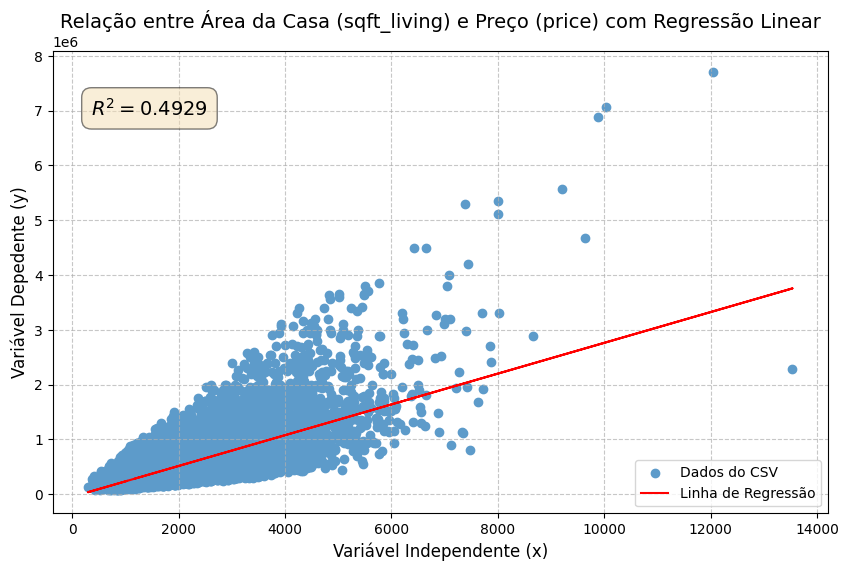

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Leitura dos dados do arquivo CSV usando numpy
# Ignoramos a primeira linha (skip_header=1) pois ela contém os cabeçalhos 'x,y'
# usecols=(5,2) → seleciona as colunas: sqft_living (x) e price (y)
dados = np.genfromtxt('kc_house_data.csv', delimiter=',', skip_header=1, usecols=(5,2))

x = dados[:, 0] # Variável Independente: sqft_living
y = dados[:, 1] # Variável Dependente: price
n = len(x)

# 2. Cálculo dos somatórios necessários para as fórmulas
sum_x = np.sum(x) # Σx
sum_y = np.sum(y) # Σy
sum_xy = np.sum(x * y)  # Σ(xy)
sum_x2 = np.sum(x ** 2)  # Σ(x²)
sum_y2 = np.sum(y ** 2)  # Σ(y²)

# 3. Cálculo da Reta de Regressão (ŷ = a + b * x)

# Calculando o coeficiente 'b'
# b = [ nΣ*(xy) − (Σx)*(Σy) ] / [ n*Σ(x²) − (Σx)² ]
b = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)

# Calculando coeficiente 'a'
# a = (Σy − b*Σx) / n
a = (sum_y - b * sum_x) / n

# Gerando os valores previstos (y_hat)
# ŷ = a + b*x
y_hat = a + b * x

# 4. Cálculo do Coeficiente de Correlação de Pearson (r)
# r = [ n*Σ(xy) − (Σx)*(Σy) ] /
#     √{ [n*Σ(x²) − (Σx)²] * [nΣ*(y²) − (Σy)²] }
numerador_r = n * sum_xy - (sum_x * sum_y)
denominador_r = np.sqrt(n * sum_x2 - sum_x**2) * np.sqrt(n * sum_y2 - sum_y ** 2)
r = numerador_r / denominador_r

# 5. Cálculo do Coeficiente de Determinação (R²)
# Média de y
y_mean = np.mean(y)

# Fórmula : Somatória de (y_hat - y_mean)² divido pelo Somatório de (y - y_mean)²
sq_reg = np.sum((y_hat - y_mean) ** 2)
sq_tot = np.sum((y-y_mean) ** 2)
r2 = sq_reg / sq_tot

# 6. Exibição dos Resultados no Console
print(f"Equação da Reta: y = {a:.4f} + {b:.4f} * x")
print(f"Coeficiente de Correlação (r): = {r:.4f}")
print(f"Coeficiente de Determinação (r²): = {r2*100:.4f}")

# 7. Visualização Gráfica dos Dados
plt.figure(figsize=(10,6))

# Gráfico de dispersão (Scatter plot) dos dados reais
plt.scatter(x, y, color='#5D9BCA', label='Dados do CSV')

# Linha de regressão gerada pelo modelo
plt.plot(x, y_hat, color='red', label="Linha de Regressão")

# Configurações de layout do gráfico
plt.title("Relação entre Área da Casa (sqft_living) e Preço (price) com Regressão Linear", fontsize=14)
plt.xlabel("Variável Independente - sqft_living (x)", fontsize=12)
plt.ylabel("Variável Depedente - price (y)", fontsize=12)

# Adiciona o valor de R² ao gráfico para fácil visualização
plt.text(
    0.05, 0.9,
    f'$R^2 = {r2:.4f}$',
    transform=plt.gca().transAxes,
    fontsize=14,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5)
)

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


### MÉTODO 2: Cálculo usando funções prontas do NumPy
#### - np.polyfit(x, y, 1) calcula a inclinação (b) e intercepto (a) automaticamente
#### - np.corrcoef(x, y) calcula o coeficiente de correlação de Pearson


Intercepto (a): -43580.7431
Inclinação (b): 280.6236

Valores previstos: [287555.06702452 677621.82640197 172499.40418656 ... 242655.29616092
 405416.96554144 242655.29616092]

Cálculo do Coeficiente de Pearson: 0.7020

Cálculo de Determinação: 49.2853


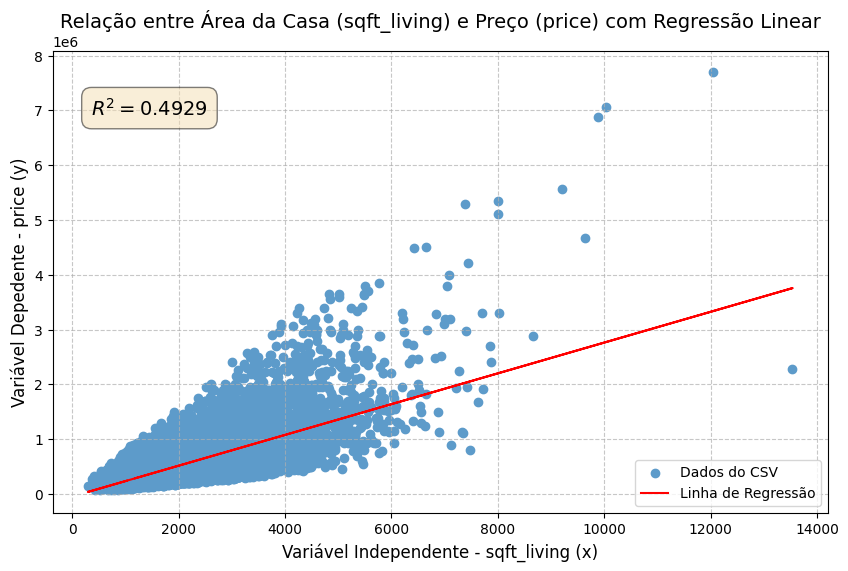

In [ ]:
# 1. Calcular os coeficientes da regressão linear (a e b)

# np.polyfit(x, y, 1) calcula os coeficientes da reta de grau 1
# Retorna: [b, a]
b, a = np.polyfit(x, y, 1)
print(f"\nIntercepto (a): {a:.4f}")
print(f"Inclinação (b): {b:.4f}")

# Valores previstos:
# ŷ = a + b*x
y_pred = a + b * x
print(f"\nValores previstos: {y_pred}")

# 2. Cálculo do Coeficiente de Correlação de Pearson (r)
# r = [ n*Σ(xy) − (Σx)*(Σy) ] /
#     √{ [n*Σ(x²) − (Σx)²] * [nΣ*(y²) − (Σy)²] }
coef_pearson = np.corrcoef(x, y)[0, 1]
print(f"\nCálculo do Coeficiente de Pearson: {coef_pearson:.4f}")

# 3. Cálculo do Coeficiente de Determinação (r²)
# Média do Y
y_mean = np.mean(y)

# r² = Σ(y_hat - y_mean)² / Σ(y - y_mean)²
sq_reg = np.sum((y_hat - y_mean) ** 2)
sq_tot = np.sum((y-y_mean) ** 2)
r2 = sq_reg / sq_tot
print(f"\nCálculo de Determinação: {r2 * 100:.4f}")

# 7. Visualização Gráfica dos Dados
plt.figure(figsize=(10,6))

# Gráfico de dispersão (Scatter plot) dos dados reais
plt.scatter(x, y, color='#5D9BCA', label='Dados do CSV')

# Linha de regressão gerada pelo modelo
plt.plot(x, y_hat, color='red', label="Linha de Regressão")

# Configurações de layout do gráfico
plt.title("Relação entre Área da Casa (sqft_living) e Preço (price) com Regressão Linear", fontsize=14)
plt.xlabel("Variável Independente - sqft_living (x)", fontsize=12)
plt.ylabel("Variável Depedente - price (y)", fontsize=12)

# Adiciona o valor de R² ao gráfico para fácil visualização
plt.text(
    0.05, 0.9,
    f'$R^2 = {r2:.4f}$',
    transform=plt.gca().transAxes,
    fontsize=14,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5)
)

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()
